# 03 — Acústica × movilidad
*¿Qué dicen los eventos sobre el lugar y la conducción?*

Une cada detección con la **velocidad** del vehículo (derivada del GPS) y estudia: fusión acústica↔movilidad (¿bocinazos a baja velocidad?), repetibilidad entre pasadas, y comparación de sensores mic vs mobile.

In [1]:
import sys, warnings
sys.path.insert(0, "../scripts")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geo_utils as gu

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.width", 140)

geo = gu.load_geo()
geo = geo[~geo["trayecto"].isin(gu.BAD_TRAYECTOS)].copy()
geo["class_name"] = geo["class"].map(gu.CLASS_NAMES)
print(f"{len(geo):,} detecciones geolocalizadas | fuentes: {geo['source'].unique().tolist()}")
geo.head(3)

14,985 detecciones geolocalizadas | fuentes: ['mic', 'mobile']


,microfono_id,t_start,t_end,class,confidence,source_file,session_id,source,date,duration_s,lat,lon,trayecto,class_name
0,1,2026-03-11 19:22:32.494373+00:00,2026-03-11 19:22:37.045898+00:00,0,0.130318,20260311_21_22_27_0739_M1.wav,20260311,mic,11-03-2026,4.551525,39.514295,-0.423465,ETSE-PAIPORTA_1,Horn
1,1,2026-03-11 19:22:36.084597+00:00,2026-03-11 19:22:36.836745+00:00,3,0.188487,20260311_21_22_27_0739_M1.wav,20260311,mic,11-03-2026,0.752148,39.514295,-0.423465,ETSE-PAIPORTA_1,Physiological
2,1,2026-03-11 19:22:36.926335+00:00,2026-03-11 19:22:37.738812+00:00,3,0.100677,20260311_21_22_32_0075_M1.wav,20260311,mic,11-03-2026,0.812477,39.514295,-0.423465,ETSE-PAIPORTA_1,Physiological


In [2]:
tracks = gu.load_tracks()
tracks = tracks[~tracks["trayecto"].isin(gu.BAD_TRAYECTOS)].copy()
tracks_sp = gu.add_speed(tracks)
# Recorte de outliers GPS (saltos de posición -> velocidades irreales)
tracks_sp.loc[tracks_sp.speed_kmh > 120, ["speed_ms", "speed_kmh", "accel_ms2"]] = np.nan
det = gu.join_speed_to_detections(geo, tracks_sp, tol_s=30)
det["class_name"] = det["class"].map(gu.CLASS_NAMES)
print(f"{len(det):,} detecciones | sin velocidad: {det.speed_ms.isna().mean()*100:.1f}%")
det[["trayecto","class_name","confidence","speed_kmh","accel_ms2"]].head()

14,985 detecciones | sin velocidad: 1.1%


,trayecto,class_name,confidence,speed_kmh,accel_ms2
0,20260523_ida,Speech,0.396334,NaN,NaN
1,20260523_ida,Speech,0.146356,62.612503,4.071502
2,20260523_ida,Speech,0.108758,46.881499,-1.748785
3,20260523_ida,Speech,0.168225,57.585844,0.044652
4,20260523_ida,Speech,0.172704,57.340986,-0.068016


## B1 — Distribución de velocidad
Perfil de velocidad de las rutas (urbano). Base para interpretar B2.

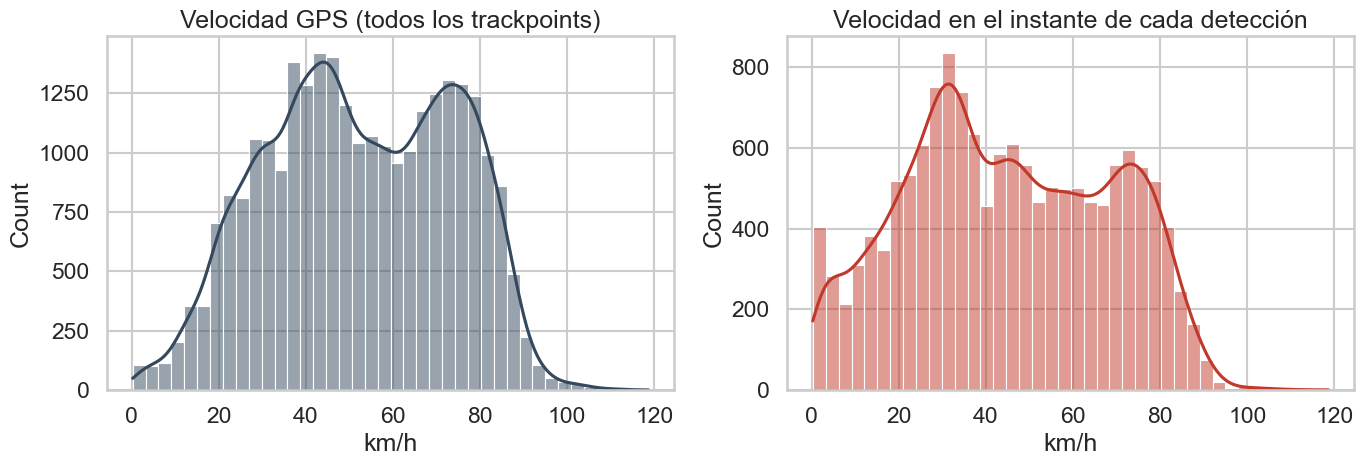

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(tracks_sp.speed_kmh.dropna(), bins=40, kde=True, ax=ax[0], color="#34495e")
ax[0].set_title("Velocidad GPS (todos los trackpoints)"); ax[0].set_xlabel("km/h")
sns.histplot(det.speed_kmh.dropna(), bins=40, kde=True, ax=ax[1], color="#c0392b")
ax[1].set_title("Velocidad en el instante de cada detección"); ax[1].set_xlabel("km/h")
plt.tight_layout(); plt.savefig("../outputs/nbB_speed_dist.png", dpi=130); plt.show()

## B2 — Fusión acústica ↔ movilidad (¿stop-and-honk?)
Hipótesis: las **bocinas (Horn)** se concentran a baja velocidad / en frenada (congestión, intersecciones). Comparamos velocidad y aceleración por clase.

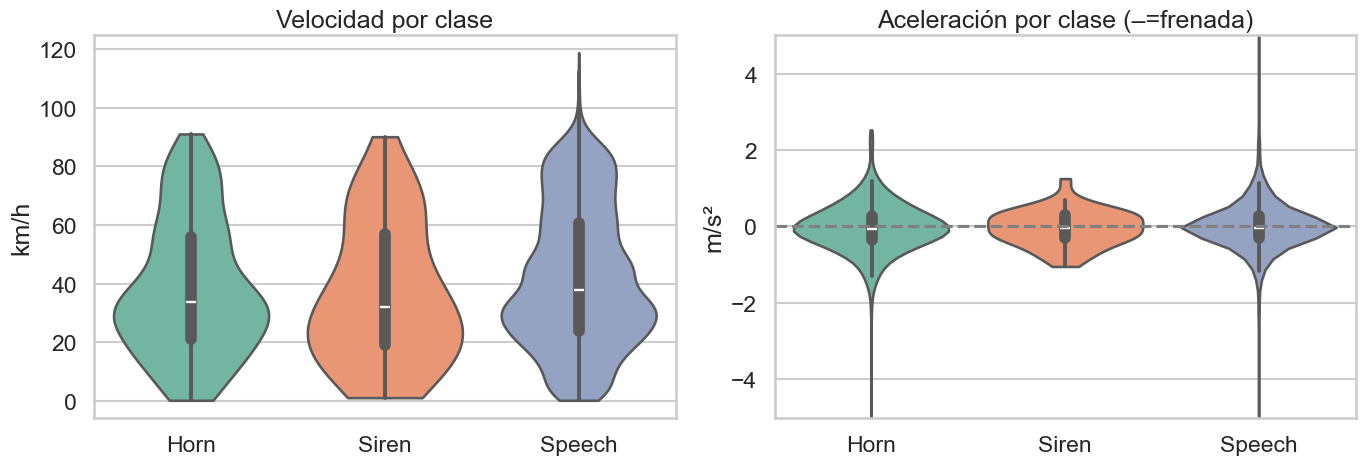

In [4]:
focus = det[det["class"].isin([0, 1, 4])].copy()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=focus, x="class_name", y="speed_kmh", ax=ax[0],
               order=["Horn","Siren","Speech"], palette="Set2", cut=0)
ax[0].set_title("Velocidad por clase"); ax[0].set_xlabel(""); ax[0].set_ylabel("km/h")
sns.violinplot(data=focus.dropna(subset=["accel_ms2"]), x="class_name", y="accel_ms2",
               ax=ax[1], order=["Horn","Siren","Speech"], palette="Set2", cut=0)
ax[1].axhline(0, color="gray", ls="--"); ax[1].set_ylim(-5, 5)
ax[1].set_title("Aceleración por clase (–=frenada)"); ax[1].set_xlabel(""); ax[1].set_ylabel("m/s²")
plt.tight_layout(); plt.savefig("../outputs/nbB_speed_by_class.png", dpi=130); plt.show()

In [5]:
LOW = 20  # km/h
tab = (det.assign(low=det.speed_kmh < LOW)
          .groupby("class_name")
          .agg(n=("low","size"), pct_low=("low","mean"),
               v_med=("speed_kmh","median"), brake_frac=("accel_ms2", lambda s:(s<-1).mean()))
          .sort_values("pct_low", ascending=False))
tab["pct_low"] = (tab.pct_low*100).round(1)
tab["brake_frac"] = (tab.brake_frac*100).round(1)
print(f"% de detecciones a <{LOW} km/h y % en frenada (<-1 m/s²) por clase:")
display(tab)

% de detecciones a <20 km/h y % en frenada (<-1 m/s²) por clase:


,n,pct_low,v_med,brake_frac
class_name,,,,
Siren,38,28.9,32.008994,2.6
Notifications,32,28.1,29.849318,6.2
Cry,93,22.6,32.782513,4.3
Horn,476,22.5,33.868358,4.2
Pets,958,21.3,37.155889,5.1
Speech,4965,18.5,37.810581,3.7
Physiological,1952,17.9,42.146854,5.0
Vibrating,3081,14.7,41.907030,4.4
Ring Tone,3390,6.8,59.681977,3.7


**Lectura.** Si Horn muestra mayor `pct_low` y `brake_frac` que Speech, respalda el patrón *stop-and-honk*: las bocinas marcan puntos de fricción del tráfico.

## B3 — Repetibilidad entre pasadas
¿El peligro acústico es propiedad **estable del lugar** o ruido? Rutas con varias pasadas (PAIPORTA↔ETSE ×6, ida/vuelta) permiten comparar densidad de eventos viales por celda espacial entre pasadas.

In [6]:
# Agrupa trayectos por corredor base (quita sufijo _N y dirección)
import re
def corridor(tr):
    base = re.sub(r"_\d+$", "", tr)
    return base
road = det[det["class"].isin(gu.ROAD_CLASSES)].copy()
road["corridor"] = road["trayecto"].apply(corridor)
passes = (det.assign(corridor=det["trayecto"].apply(corridor))
             .groupby(["corridor","trayecto"]).size())
multi = passes.groupby("corridor").size()
multi = multi[multi > 1].index.tolist()
print("Corredores con varias pasadas:", multi)

Corredores con varias pasadas: ['ETSE-PAIPORTA', 'PAIPORTA-ETSE', 'PAIPORTA-SILLA', 'SILLA-MASANASA']


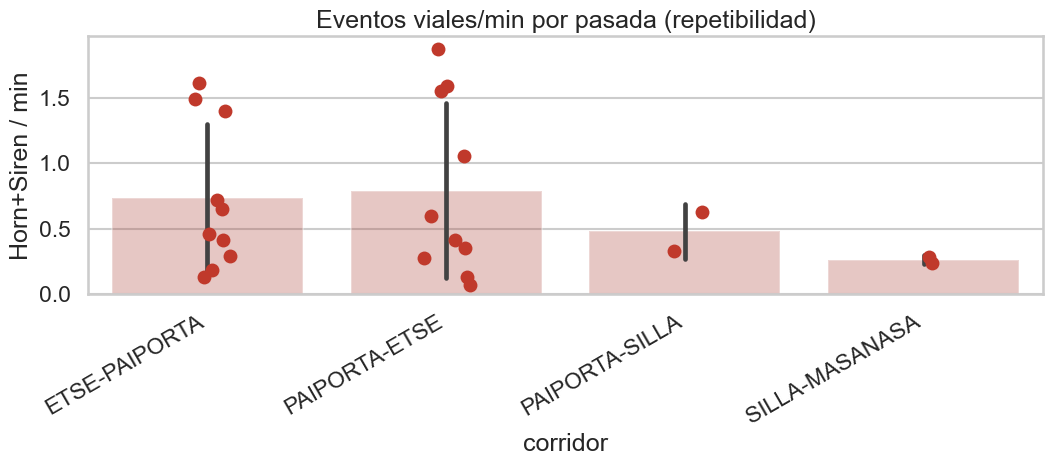

,mean,std,count
corridor,,,
ETSE-PAIPORTA,0.737,0.562,10
PAIPORTA-ETSE,0.791,0.670,10
PAIPORTA-SILLA,0.480,0.207,2
SILLA-MASANASA,0.264,0.034,2


In [7]:
# Densidad de eventos viales por minuto en cada pasada de corredores repetidos
dur = (det.groupby("trayecto")
          .agg(t0=("t_start","min"), t1=("t_start","max")))
dur["min"] = (dur.t1 - dur.t0).dt.total_seconds()/60
rate = (road.groupby(["corridor","trayecto"]).size().rename("n_road").reset_index()
            .merge(dur["min"], on="trayecto"))
rate["road_per_min"] = rate.n_road / rate["min"].replace(0, np.nan)
rate = rate[rate.corridor.isin(multi)]
if not rate.empty:
    fig, ax = plt.subplots(figsize=(11,5))
    sns.stripplot(data=rate, x="corridor", y="road_per_min", size=10, ax=ax, color="#c0392b")
    sns.barplot(data=rate, x="corridor", y="road_per_min", ax=ax, alpha=.3, color="#c0392b", errorbar="sd")
    ax.set_title("Eventos viales/min por pasada (repetibilidad)"); ax.set_ylabel("Horn+Siren / min")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout()
    plt.savefig("../outputs/nbB_repeatability.png", dpi=130); plt.show()
    display(rate.groupby("corridor").road_per_min.agg(["mean","std","count"]).round(3))
else:
    print("Sin corredores repetidos con eventos viales.")

**Lectura.** Baja dispersión entre pasadas de un mismo corredor → el evento acústico es propiedad reproducible del lugar (apoya el danger score). Alta dispersión → dependencia del momento/tráfico puntual (limitación).

## B4 — Comparación de sensores: mic (fijo) vs mobile (smartphone)
Dos sistemas de captura sobre la misma área metropolitana. ¿Coinciden en la mezcla de clases y en la tasa de detección normalizada por duración?

Detecciones/min por fuente:
source
mic       31.89
mobile    14.65
dtype: float64


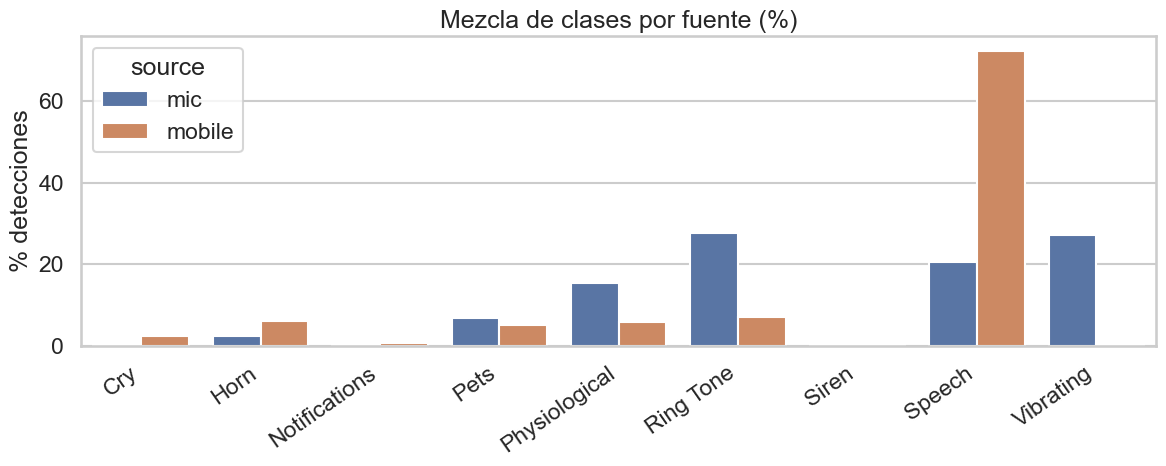

In [8]:
dur_src = (det.groupby(["source","trayecto"])
              .agg(t0=("t_start","min"), t1=("t_start","max"))
              .assign(min=lambda d:(d.t1-d.t0).dt.total_seconds()/60)
              .groupby("source")["min"].sum())
n_src = det.groupby("source").size()
print("Detecciones/min por fuente:")
print((n_src / dur_src).round(2))
mix = det.groupby(["source","class_name"]).size().rename("n").reset_index()
mix["pct"] = mix.groupby("source")["n"].transform(lambda s: 100*s/s.sum())
fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(data=mix, x="class_name", y="pct", hue="source", ax=ax)
ax.set_title("Mezcla de clases por fuente (%)"); ax.set_xlabel(""); ax.set_ylabel("% detecciones")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/nbB_source_mix.png", dpi=130); plt.show()

### Salida del notebook
- `det` con velocidad/aceleración por detección (insumo de NB-04).
- Evidencia stop-and-honk (B2), repetibilidad por corredor (B3), sesgo de sensor (B4).